# **Prédiction du Prix de Vente de Maisons avec lightgbm, xgboost, catboost**

## **1. Importer les bibliothèques standards**

- pandas, numpy pour la manipulation des données,
- matplotlib / seaborn pour la visualisation,
- sklearn pour le pré-traitement, la validation croisée, les métriques et les utilitaires.

In [1]:
import pandas as pd
import numpy as np
import sklearn as sk
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold, ParameterSampler
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.utils import check_random_state

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


## **2. Choix des modèles pour la prédiction**

Nous utilisons 3 algorithmes de gradient boosting : CatBoost, LightGBM et XGBoost.

Pourquoi ces trois ?

Ce sont des algorithmes d’arbres de décision boostés largement utilisés en compétition (robustesse, vitesse, qualité).

Ils sont complémentaires :
- XGBoost : robuste, bon contrôle de la régularisation, souvent performant.
- LightGBM : très rapide sur grands jeux de données, gère automatiquement les features catégorielles si on les convertit en category.
- CatBoost : gère nativement les variables catégorielles (encodage ciblé) et évite certains biais lors de l’encodage ; souvent très performant sans beaucoup d’ingénierie.

L’ensemble (mélange/stacking) de ces modèles tend à réduire la variance et améliorer la robustesse.

In [2]:
# Importer les modèles
try:
    from lightgbm import LGBMRegressor
except:
    LGBMRegressor = None
    print("Warning: lightgbm not installed.")
try:
    from xgboost import XGBRegressor
except:
    XGBRegressor = None
    print("Warning: xgboost not installed.")
try:
    from catboost import CatBoostRegressor
except:
    CatBoostRegressor = None
    print("Warning: catboost not installed.")

## **3. Chargeons les données**

In [ ]:
# Paths for Kaggle
train_file_path = "../input/house-prices-advanced-regression-techniques/train.csv"
test_file_path = "../input/house-prices-advanced-regression-techniques/test.csv"

# Chargement des données
print("Loading data...")
train = pd.read_csv(train_file_path)
test = pd.read_csv(test_file_path)
test_ids = test["Id"].copy()
y = train["SalePrice"].values
y_log = np.log1p(y)

# Affichage des premières lignes
print(f"\n-------------------- Train Data --------------------\n", train.head())
print(f"\n-------------------- Test Data --------------------\n", test.head())

# Affichage des dimensions
print(f"\n Train shape:", train.shape)
print(f"\n Test shape:", test.shape)

## **4. Analyse exploratoire**
- Comprendre la distribution de la cible (SalePrice),
- Repérer des valeurs extrêmes / outliers,
- Identifier types des colonnes (numériques vs catégorielles),
- Mesurer corrélations simples entre features numériques et la cible.

In [ ]:
train_copy = train.copy().drop('Id', axis=1)
test_copy = test.copy().drop('Id', axis=1)

train_copy.head(3), test_copy.head(3)

In [ ]:
train_copy.info()

## **4.1 Distribution de la variable cible SalePrice (histogramme)**

In [ ]:
print(train_copy['SalePrice'].describe())
plt.figure(figsize=(9, 8))## **4.1 Distribution de la variable cible SalePrice (histogramme)**
plt.hist(train_copy['SalePrice'], color='g', edgecolor='black', bins=100, alpha=0.4)
plt.xlabel('SalePrice')
plt.ylabel('Frequency')
plt.title('Distribution of SalePrice')
plt.show()

La différence entre la moyenne (180 921) et la médiane (163 000) montre que :
- La moyenne est plus élevée que la médiane, ce qui indique une asymétrie à droite. Cela signifie qu’il existe des ventes beaucoup plus chères qui tirent la moyenne vers le haut.
- L'écart-type de 79 442 est pratiquement la moitié de la moyenne. Cela signifie que les prix des maisons varient énormément.
- Le ratio max/min est très élevé (755 000 / 34 900 ≈ 21,6). Cela indique qu'il y a quelques maisons très luxueuses, ou très grandes, qui font partie des extrêmes du dataset.


En conclusion, la variable SalePrice est positive, fortement asymétrique à droite, possède une grande variabilité et contient des valeurs extrêmes. D'où la nécessité d'une transformation logarithmique pour être mieux modélisée.


## **4.2 Distribution de la variable cible SalePrice (boxplot)**

In [ ]:
plt.figure(figsize=(10, 5))
plt.boxplot(train_copy['SalePrice'], patch_artist=True, boxprops=dict(facecolor='lightgreen'))
plt.ylabel('SalePrice')
plt.title('Boxplot of SalePrice')
plt.show()

- La ligne médiane décalée vers le bas de la boîte, le “whisker” supérieur plus long que l’inférieur: ce qui confirme que la distribution de la variable SalePrice est assymétrique à droite.
- La boxplot met en évidence les valeurs extrêmes (points situés a l'extérieur des moustaches)

In [ ]:
list(set(train_copy.dtypes.tolist()))

In [9]:
train_num = train_copy.select_dtypes(include = ['float64', 'int64'])
train_num.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,0,61,0,0,0,0,0,2,2008,208500
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,298,0,0,0,0,0,0,5,2007,181500
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,0,42,0,0,0,0,0,9,2008,223500
3,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,0,35,272,0,0,0,0,2,2006,140000
4,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,192,84,0,0,0,0,0,12,2008,250000


## **4.3 Distribution de toutes les variables numériques (histogramme)**

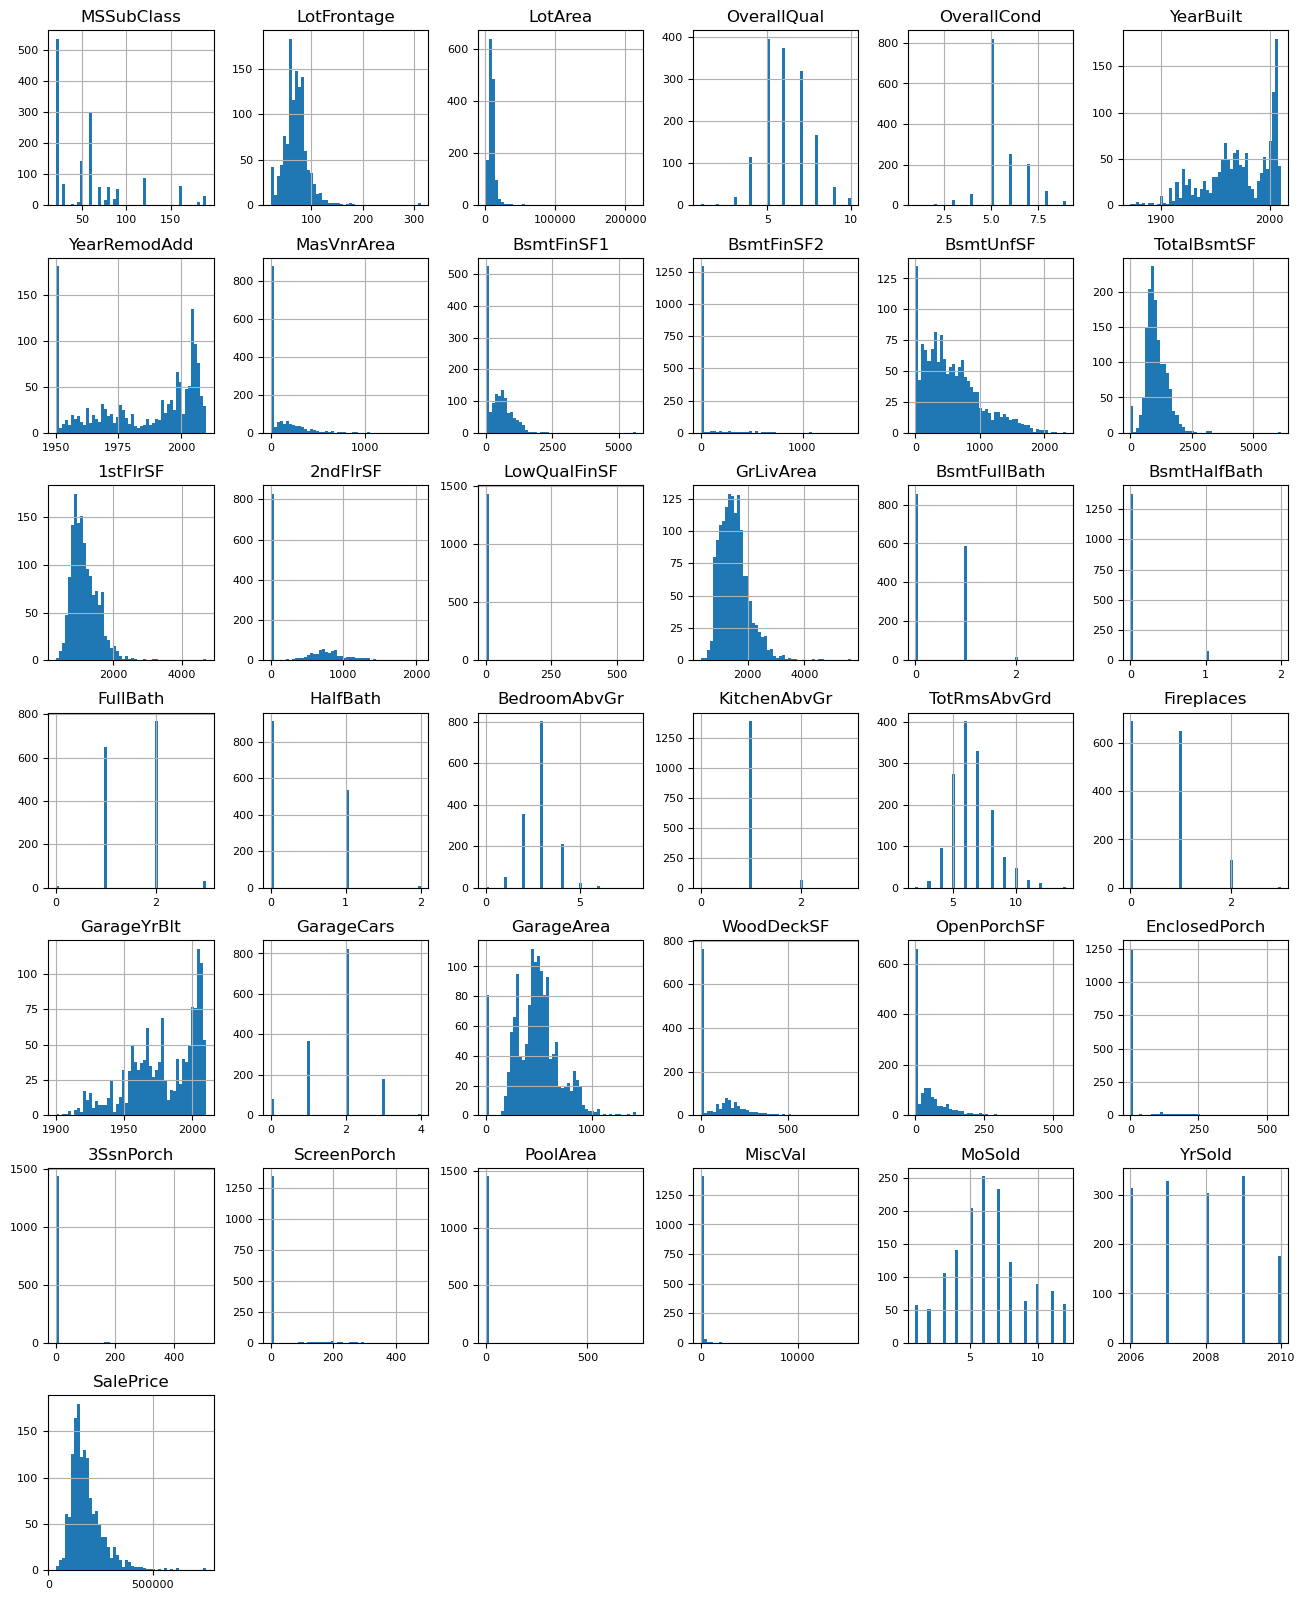

In [10]:
train_num.hist(figsize=(16, 20), bins=50, xlabelsize=8, ylabelsize=8);

## **4.4 Analyse des corrélations entre les variables numériques et la variable SalePrice**

On calcule ici la corrélation entre chaque variable numérique et la variable cible SalePrice. Cela permet d’identifier rapidement quelles caractéristiques sont les plus fortement liées au prix de vente, même si la corrélation linéaire n’est pas suffisante pour capturer toutes les relations non linéaires dans les modèles de boosting.

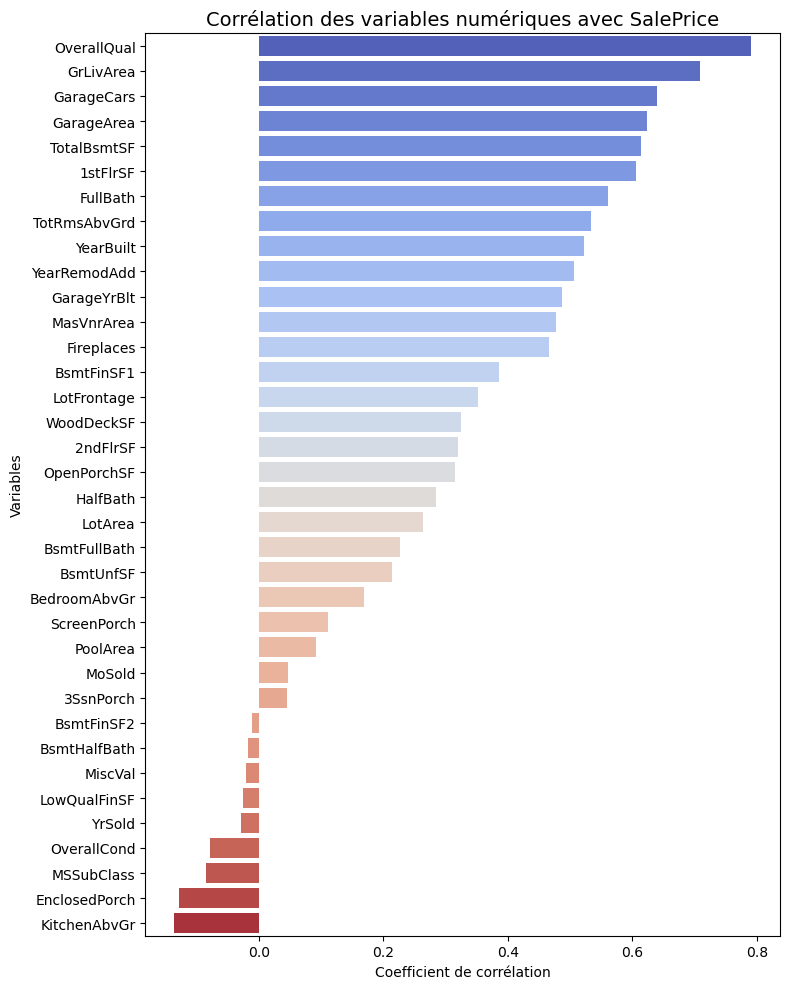

In [11]:
# corrélation entre chaque variable numérique et la variable cible SalePrice
correlation_with_target = (
    train_num.corr()['SalePrice']        # matrice de corrélation, on extrait la colonne SalePrice
    .drop('SalePrice')                   # on retire SalePrice elle-même
    .sort_values(ascending=False)        # tri décroissant pour voir les plus corrélées en haut
)

# --- Visualisation des corrélations avec SalePrice ---
# On affiche ici un barplot pour visualiser les coefficients de corrélation.
# Cela donne un aperçu clair et intuitif des variables numériques les plus informatives.
plt.figure(figsize=(8, 10))
sns.barplot(
    x=correlation_with_target.values, 
    y=correlation_with_target.index, 
    palette="coolwarm"                   # palette avec dégradé pour une lecture plus agréable
)
plt.title("Corrélation des variables numériques avec SalePrice", fontsize=14)
plt.xlabel("Coefficient de corrélation")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()


## **5. Fonctions de traitement des données (preprocessing)**

**Objectif  :** Construire des jeux d’entraînement et de test compatibles avec chaque modèle (LightGBM, XGBoost, CatBoost), tout en conservant un ensemble de métadonnées permettant d’appliquer exactement le même pipeline au jeu de test.

**1. Distinction des types de variables**
    - Séparer features numériques et features catégorielles.
    - Cela simplifie l’imputation, l’encodage et la compatibilité entre modèles.

**2. Imputation des valeurs manquantes**
    - Numériques → médiane: Plus robuste que la moyenne en présence d’outliers.
    - Catégorielles → "Missing": Traite explicitement les valeurs manquantes en tant que catégorie.

**3. Suppression des colonnes avec trop de valeurs manquantes**
    - Si une colonne dépasse un seuil configurable de taux de NA, on la supprime.
    - Le nom de ces colonnes est conservé dans les métadonnées.

**4. Cohérence train/test**

Tous les encodeurs, listes de colonnes, valeurs imputées, etc. sont enregistrés dans metadata. preprocess_test() peut ainsi reproduire exactement les mêmes opérations sur le test.

**- Encodage selon le modèle**

    - XGBoost ne gère pas les category nativement → encodages nécessaires.
    
          1. One-Hot Encoding pour les colonnes à faible cardinalité
          2. Ordinal Encoding pour les colonnes à forte cardinalité
          
    - LightGBM & CatBoost
    
          1. Les colonnes catégorielles sont conservées comme category.
          2. LightGBM et CatBoost savent traiter ces types nativement, sans One-Hot. CatBoost reçoit en plus la liste des colonnes catégorielles directement et applique ses propres encodages optimisés.



**- Métadonnées enregistrées (metadata)**

Ce dictionnaire conserve tous les éléments nécessaires pour reproduire le preprocessing :
    - dropped — colonnes supprimées
    - medians — valeurs d’imputation numérique
    - numeric_cols — colonnes numériques finales
    - low_card / high_card — catégorielles segmentées selon la cardinalité
    - ohe, ord_enc — encodeurs entraînés (pour XGBoost)
    - feature_names — ordre final des colonnes après encodage

In [12]:
# ------------------- Fonction de prétraitement pour l'entraînement -------------------
def preprocess_train(df, model="xgboost", missing_threshold=80, low_cardinality=3, random_state=42):
    """
    Prétraitement appliqué aux données d'entraînement.
    Retourne :
        - X_proc : DataFrame prétraité
        - y : variable cible (si présente)
        - ids : identifiants 'Id' (si présents)
        - metadata : dictionnaire contenant toutes les informations nécessaires
                     pour reproduire exactement le même prétraitement sur les données test.
    """
    
    # On travaille sur une copie pour éviter de modifier les données originales
    df = df.copy()

    # Séparation de la cible et de l'identifiant s'ils sont présents
    y = df.pop("SalePrice") if "SalePrice" in df.columns else None
    ids = df.pop("Id") if "Id" in df.columns else None

    # ---------------- Suppression des colonnes trop manquantes ----------------
    # On calcule le pourcentage de valeurs manquantes dans chaque colonne
    missing_pct = df.isnull().mean() * 100
    # On supprime les colonnes dépassant un seuil défini (par défaut 80 %)
    dropped = missing_pct[missing_pct > missing_threshold].index.tolist()
    df = df.drop(columns=dropped)

    # ---------------- Séparation numérique / catégorielle ----------------
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

    # ---------------- Imputation des colonnes numériques ----------------
    # On remplace les valeurs manquantes par la médiane, ce qui est robuste aux valeurs extrêmes
    medians = {c: df[c].median() for c in numeric_cols}
    num_imp = SimpleImputer(strategy="median")
    if numeric_cols:
        df[numeric_cols] = num_imp.fit_transform(df[numeric_cols])

    # ---------------- Traitement des colonnes catégorielles ----------------
    # On remplace les valeurs manquantes par une catégorie explicite "Missing"
    for c in cat_cols:
        df[c] = df[c].fillna("Missing").astype(str)

    # On sépare les colonnes catégorielles selon leur cardinalité
    # Faible cardinalité → One-Hot Encoding
    # Forte cardinalité → Ordinal Encoding
    low_card = [c for c in cat_cols if df[c].nunique() <= low_cardinality]
    high_card = [c for c in cat_cols if c not in low_card]

    # ------------------- Construction des metadata -------------------
    metadata = {
        "dropped": dropped,
        "medians": medians,
        "numeric_cols": numeric_cols,
        "low_card": low_card,
        "high_card": high_card,
        "model": model.lower()
    }

    model = model.lower()

    # ======================================================================================
    # ---------------------------- Cas des modèles XGBoost --------------------------------
    # ======================================================================================
    if model == "xgboost":

        # Initialisation des encodeurs
        ohe = None
        ord_enc = None
        ohe_df = pd.DataFrame(index=df.index)
        ord_df = pd.DataFrame(index=df.index)

        # ------- One-Hot Encoding pour les variables à faible cardinalité -------
        if low_card:
            ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)
            ohe_arr = ohe.fit_transform(df[low_card])
            ohe_df = pd.DataFrame(ohe_arr, columns=ohe.get_feature_names_out(low_card), index=df.index)

        # ------- Ordinal Encoding pour les variables à forte cardinalité -------
        if high_card:
            ord_enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
            ord_arr = ord_enc.fit_transform(df[high_card])
            ord_df = pd.DataFrame(np.floor(ord_arr).astype(int), columns=high_card, index=df.index)

        # ------- Assemblage final des données prétraitées -------
        X_proc = pd.concat(
            [
                df[numeric_cols].reset_index(drop=True),
                ord_df.reset_index(drop=True),
                ohe_df.reset_index(drop=True)
            ],
            axis=1
        )

        feature_names = X_proc.columns.tolist()

        metadata.update({
            "ohe": ohe,
            "ord_enc": ord_enc,
            "feature_names": feature_names
        })

        return X_proc, y, ids, metadata

    # ======================================================================================
    # ------------------- Cas LightGBM et CatBoost (gèrent eux-mêmes les catégories) -------
    # ======================================================================================
    elif model in ("lightgbm", "catboost"):

        # Pour ces modèles, on garde les catégories en dtype "category"
        for c in low_card + high_card:
            df[c] = df[c].astype("category")

        feature_cols = numeric_cols + low_card + high_card
        X_proc = df[feature_cols].copy()

        metadata.update({
            "cat_cols": low_card + high_card,
            "feature_names": feature_cols
        })

        return X_proc, y, ids, metadata

    else:
        raise ValueError("Modèle non supporté. Choisir 'xgboost', 'lightgbm' ou 'catboost'.")



# ------------------- Fonction de prétraitement pour les données test -------------------
def preprocess_test(df, metadata):
    """
    Applique exactement les mêmes transformations que celles apprises sur les données d'entraînement.
    Permet d'assurer que les colonnes produites sont dans le même ordre et avec les mêmes noms.
    """
    
    df = df.copy()
    model = metadata.get("model", "xgboost").lower()

    # ---------------- Reproduction des suppressions de colonnes ----------------
    df = df.drop(columns=[c for c in metadata.get("dropped", []) if c in df.columns], errors='ignore')

    # Suppression éventuelle de Id ou SalePrice si présents
    df = df.drop(columns=["Id", "SalePrice"], errors='ignore')

    # ---------------- Imputation numérique identique à l'entraînement ----------------
    for c, med in metadata.get("medians", {}).items():
        if c not in df.columns:
            df[c] = med
        df[c] = df[c].fillna(med)

    # ---------------- Traitement des catégories ----------------
    for c in metadata.get("low_card", []) + metadata.get("high_card", []):
        if c not in df.columns:
            df[c] = "Missing"
        df[c] = df[c].fillna("Missing").astype(str)

    # ======================================================================================
    # ---------------------------- Prétraitement XGBoost -----------------------------------
    # ======================================================================================
    if model == "xgboost":
        ohe = metadata.get("ohe", None)
        ord_enc = metadata.get("ord_enc", None)
        numeric_cols = metadata.get("numeric_cols", [])

        # ------------ Reconstruction du bloc numérique ------------
        numeric_df = pd.DataFrame(
            {c: df.get(c, metadata["medians"].get(c, 0)) for c in numeric_cols},
            index=df.index
        )

        # ------------ Transformation ordinale ------------
        if metadata.get("high_card"):
            ord_arr = ord_enc.transform(df[metadata["high_card"]])
            ord_df = pd.DataFrame(np.floor(ord_arr).astype(int), columns=metadata["high_card"], index=df.index)
        else:
            ord_df = pd.DataFrame(index=df.index)

        # ------------ One-hot encoding ------------
        if metadata.get("low_card"):
            ohe_arr = ohe.transform(df[metadata["low_card"]])
            ohe_df = pd.DataFrame(ohe_arr, columns=ohe.get_feature_names_out(metadata["low_card"]), index=df.index)
        else:
            ohe_df = pd.DataFrame(index=df.index)

        # ------------ Assemblage final ------------
        X_proc = pd.concat(
            [
                numeric_df.reset_index(drop=True),
                ord_df.reset_index(drop=True),
                ohe_df.reset_index(drop=True)
            ],
            axis=1
        )

        # Dans de rares cas, une catégorie présente en train peut ne pas apparaître en test
        # → on ajoute les colonnes manquantes et on les remplit avec 0
        for col in metadata["feature_names"]:
            if col not in X_proc.columns:
                X_proc[col] = 0

        X_proc = X_proc[metadata["feature_names"]]

        return X_proc

    # ======================================================================================
    # -------------------- Prétraitement LightGBM / CatBoost ------------------------------
    # ======================================================================================
    else:
        for c in metadata.get("cat_cols", []):
            if c not in df.columns:
                df[c] = "Missing"
            df[c] = df[c].astype("category")

        X_proc = df[metadata["feature_names"]].copy()
        return X_proc


## **5.1 Traitement des données**

In [13]:
random_state = 42

# =====================================================================
#                           CATBOOST
# =====================================================================
print("Prétraitement pour CatBoost...")

# On applique notre fonction preprocess_train sur le jeu d'entraînement
# - Elle renvoie : X_train prétraité, y, ids, metadata
X_train_cat, _, _, meta_cat = preprocess_train(
    train.copy(),
    model="catboost",
    random_state=random_state
)

# On applique preprocess_test au jeu test avec le même metadata
# pour reproduire EXACTEMENT les mêmes transformations
X_test_cat = preprocess_test(test.copy(), meta_cat)

# Affichage pour vérification
print(f"\n-------------------- X_train CatBoost --------------------\n", X_train_cat.head())
print(f"\n-------------------- X_test CatBoost --------------------\n", X_test_cat.head())



# =====================================================================
#                           LIGHTGBM
# =====================================================================
print("Prétraitement pour LightGBM...")

# Même logique : CatBoost et LGBM traitent les catégories différemment,
# d'où un prétraitement dédié.
X_train_lgb, _, _, meta_lgb = preprocess_train(
    train.copy(),
    model="lightgbm",
    random_state=random_state
)

X_test_lgb = preprocess_test(test.copy(), meta_lgb)

# Affichage pour contrôle visuel
print(f"\n-------------------- X_train LightGBM --------------------\n", X_train_lgb.head())
print(f"\n-------------------- X_test LightGBM --------------------\n", X_test_lgb.head())



# =====================================================================
#                           XGBOOST
# =====================================================================
print("Prétraitement pour XGBoost...")

# Prétraitement plus complexe : XGBoost ne gère pas les catégories → encodage obligatoire
X_train_xgb, _, _, meta_xgb = preprocess_train(
    train.copy(),
    model="xgboost",
    random_state=random_state
)

X_test_xgb = preprocess_test(test.copy(), meta_xgb)

# Affichage du résultat final
print(f"\n-------------------- X_train XGBoost --------------------\n", X_train_xgb.head())
print(f"\n-------------------- X_test XGBoost --------------------\n", X_test_xgb.head())


Prétraitement pour CatBoost...

-------------------- X_train CatBoost --------------------
    MSSubClass  LotFrontage  LotArea  OverallQual  OverallCond  YearBuilt  \
0        60.0         65.0   8450.0          7.0          5.0     2003.0   
1        20.0         80.0   9600.0          6.0          8.0     1976.0   
2        60.0         68.0  11250.0          7.0          5.0     2001.0   
3        70.0         60.0   9550.0          7.0          5.0     1915.0   
4        60.0         84.0  14260.0          8.0          5.0     2000.0   

   YearRemodAdd  MasVnrArea  BsmtFinSF1  BsmtFinSF2  ...  Electrical  \
0        2003.0       196.0       706.0         0.0  ...       SBrkr   
1        1976.0         0.0       978.0         0.0  ...       SBrkr   
2        2002.0       162.0       486.0         0.0  ...       SBrkr   
3        1970.0         0.0       216.0         0.0  ...       SBrkr   
4        2000.0       350.0       655.0         0.0  ...       SBrkr   

   KitchenQual  Fu

## **6. Fonctions utilitaires**

### **1) Fonction rmse_log**

**Objectif:** Calculer l’erreur RMSE sur la target transformée en log.

Pourquoi utiliser le log ?
Dans le challenge House Prices, les prix suivent une distribution très asymétrique :
- le log stabilise la variance,
- il réduit l’influence des outliers,
- et rend la métrique plus cohérente pour une régression.

### **2) Fonction cross_validate_model**

**Objectif** 

Effectuer une cross-validation complète avec :
- splits K-Fold,
- early stopping,
- OOF predictions,
- moyenne des prédictions sur le test,
- calcul du RMSE(log) pour chaque fold.

**Pourquoi cette fonction est indispensable?**

- Évalue efficacement chaque combinaison d’hyperparamètres.
- Utilise early stopping, accélère l'entraînement et évite l’overfitting.
- Génère OOF prédictions (nécessaires pour stacking/blending).
- Stabilise les prédictions en moyenne des folds.
- Compatible 100% avec CatBoost / LightGBM / XGBoost, même en cas de versions différentes.

In [14]:
# ---------------- utils ----------------
def rmse_log(y_true_log, y_pred_log):
    return np.sqrt(mean_squared_error(y_true_log, y_pred_log))


# ---------------- cross-validation function with early stopping ----------------
def cross_validate_model(model_constructor, model_name, X, y_log, X_test, metadata,
                         n_splits=5, random_state=42, early_stopping_rounds=100, verbose=False):
    """
    Fonction de validation croisée avec support du early stopping.
    Cette fonction effectue :
    - K-Fold CV
    - Prédictions OOF sur l'ensemble d'entraînement
    - Prédictions moyennes sur le test
    - Calcul du RMSE log pour chaque fold

    Args:
        model_constructor : callable ou instance de modèle
        model_name (str) : 'lightgbm', 'catboost' ou 'xgboost'
        X (DataFrame) : données d'entraînement prétraitées
        y_log (array) : target transformée avec log1p
        X_test (DataFrame) : données de test prétraitées
        metadata (dict) : informations de prétraitement (colonnes, encoders, etc.)
        n_splits (int) : nombre de folds pour CV
        random_state (int) : seed pour reproductibilité
        early_stopping_rounds (int) : nombre d'itérations sans amélioration avant arrêt
        verbose (bool) : afficher le RMSE de chaque fold

    Returns:
        dict contenant :
            - name : nom du modèle
            - mean_rmse : RMSE moyen
            - std_rmse : écart-type des RMSE
            - fold_scores : liste des RMSE par fold
            - oof_preds : prédictions out-of-fold
            - test_preds_avg : prédiction finale sur test (moyenne folds)
    """
    rng = check_random_state(random_state)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    oof_preds = np.zeros(X.shape[0])
    test_preds_folds = np.zeros((X_test.shape[0], n_splits))
    fold_scores = []

    # Boucle sur les folds
    for fold, (train_idx, valid_idx) in enumerate(kf.split(X)):
        X_tr, X_val = X.iloc[train_idx], X.iloc[valid_idx]
        y_tr, y_val = y_log[train_idx], y_log[valid_idx]

        # Instanciation du modèle (si callable)
        model = model_constructor() if callable(model_constructor) else model_constructor

        mname = model_name.lower()

        # ---------------- Branch LightGBM ----------------
        if mname == "lightgbm":
            cat_feats = metadata.get("cat_cols", [])

            # Détection des callbacks disponibles (versions modernes de LightGBM)
            use_callbacks = False
            try:
                from lightgbm import early_stopping as lgb_early_stopping, log_evaluation as lgb_log_evaluation
                use_callbacks = True
            except Exception:
                pass

            if use_callbacks:
                callbacks = [lgb_early_stopping(stopping_rounds=early_stopping_rounds),
                             lgb_log_evaluation(period=0)]

                # Vérifie si les colonnes catégorielles sont déjà en dtype 'category'
                send_categorical_feature = True
                if cat_feats:
                    all_cat_dtype = all([pd.api.types.is_categorical_dtype(X_tr[col]) for col in cat_feats if col in X_tr.columns])
                    send_categorical_feature = not all_cat_dtype

                if send_categorical_feature:
                    model.fit(X_tr, y_tr,
                              eval_set=[(X_val, y_val)],
                              callbacks=callbacks)
                else:
                    model.fit(X_tr, y_tr,
                              eval_set=[(X_val, y_val)],
                              callbacks=callbacks)
            else:
                # fallback pour versions anciennes de LightGBM
                try:
                    model.fit(X_tr, y_tr,
                              eval_set=[(X_val, y_val)],
                              early_stopping_rounds=early_stopping_rounds,
                              verbose=False)
                except TypeError:
                    model.fit(X_tr, y_tr)

        # ---------------- Branch CatBoost ----------------
        elif mname == "catboost":
            cat_feats = metadata.get("cat_cols", [])
            model.fit(X_tr, y_tr,
                      eval_set=[(X_val, y_val)],
                      cat_features=cat_feats,
                      use_best_model=True,
                      early_stopping_rounds=early_stopping_rounds,
                      verbose=False)

        # ---------------- Branch XGBoost ----------------
        else:  # xgboost
            try:
                model.fit(X_tr, y_tr,
                          eval_set=[(X_val, y_val)],
                          early_stopping_rounds=early_stopping_rounds,
                          verbose=False)
            except TypeError:
                # fallback si la version sklearn de XGBoost ne supporte pas early_stopping
                model.fit(X_tr, y_tr)

        # Prédictions sur fold de validation
        val_pred = model.predict(X_val)
        oof_preds[valid_idx] = val_pred

        # Calcul RMSE log pour ce fold
        fold_rmse = mean_squared_error(y_val, val_pred, squared=False)
        fold_scores.append(float(fold_rmse))

        # Prédictions sur test pour ce fold
        test_preds_folds[:, fold] = model.predict(X_test)

        if verbose:
            print(f"{model_name} - Fold {fold+1}/{n_splits} RMSE(log) = {fold_rmse:.5f}")

    # RMSE moyen et écart-type sur les folds
    mean_rmse = float(np.mean(fold_scores))
    std_rmse = float(np.std(fold_scores))
    # Prédiction finale sur test = moyenne des folds
    test_preds_avg = test_preds_folds.mean(axis=1)

    return {
        "name": model_name,
        "mean_rmse": mean_rmse,
        "std_rmse": std_rmse,
        "fold_scores": fold_scores,
        "oof_preds": oof_preds,
        "test_preds_avg": test_preds_avg
    }


### **3) Fonction sample_params**

Échantillonner n_iter configurations d’hyperparamètres à partir d’un espace qui peut contenir :
- des listes (valeurs discrètes),
- des objets de distribution (scipy.stats / sklearn loguniform / randint / uniform), i.e. des distributions continues ou entières.
- Garantir la reproductibilité (seed), la compatibilité et un comportement homogène pour toutes les clés de la grille.

### **4) Fonction tune_model**

Pour chaque configuration échantillonnée :
- lancer une cross-validation (via cross_validate_model) avec early stopping,
- mesurer la performance (RMSE(log)),
- conserver la meilleure configuration et ses prédictions sur X_test.
- Fournir un report clair pour chaque modele (meilleurs hyperparamètres, score, prédictions moyennées)

In [15]:
# ---------------- Recherche d'hyperparamètres ----------------

def sample_params(grid, n_iter=10, random_state=42):
    """
    Prélève aléatoirement un certain nombre de combinaisons d’hyperparamètres
    à partir d'une grille (ParamGrid ou distributions). 
    Permet d’explorer un sous-ensemble de la grille sans tout tester.
    """
    sampled_params = []
    rng = np.random.RandomState(random_state)
    
    for _ in range(n_iter):
        params = {}
        for k, v in grid.items():
            # Si v est une distribution scipy
            if hasattr(v, "rvs"):
                params[k] = v.rvs(random_state=rng)
            else:  # sinon liste ou valeur fixe
                params[k] = rng.choice(v)
        sampled_params.append(params)
    
    return sampled_params


def tune_model(model_name, param_grid, X, y_log, X_test, metadata,
               n_splits=3, n_iter=8, random_state=42,
               early_stopping_rounds=100, verbose=True):
    """
    Recherche d’hyperparamètres pour un modèle donné en utilisant Random Search
    + cross-validation avec early stopping.

    Paramètres :
    - model_name : nom du modèle ("catboost", "lightgbm", "xgboost")
    - param_grid : grille ou distributions d’hyperparamètres
    - X, y_log : données d’entraînement
    - X_test : données test à prédire
    - metadata : informations spécifiques (ex : colonnes catégorielles)
    - n_splits : nombre de folds CV
    - n_iter : nombre de tirages aléatoires dans la grille
    - early_stopping_rounds : patience pour l’early stopping
    - verbose : affichage du progrès

    Retour :
    - meilleurs hyperparamètres trouvés
    - meilleur score RMSE(log)
    - prédictions moyennées sur X_test
    """

    # Tire n_iter combinaisons aléatoires
    samples = sample_params(param_grid, n_iter=n_iter, random_state=random_state)

    best_score = float("inf")
    best_params = None
    best_preds = None

    for params in samples:
        mname = model_name.lower()

        if mname == "catboost":
            model_ctor = lambda p=params: CatBoostRegressor(
                **p,
                loss_function='RMSE',
                random_seed=random_state,
                verbose=0
            )
        elif mname == "lightgbm":
            model_ctor = lambda p=params: LGBMRegressor(
                **p,
                random_state=random_state,
                n_jobs=-1
            )
        else:  # XGBoost
            model_ctor = lambda p=params: XGBRegressor(
                **p,
                verbosity=0,
                random_state=random_state,
                n_jobs=-1
            )

        # Cross-validation
        res = cross_validate_model(
            model_constructor=model_ctor,
            model_name=model_name,
            X=X,
            y_log=y_log,
            X_test=X_test,
            metadata=metadata,
            n_splits=n_splits,
            random_state=random_state,
            early_stopping_rounds=early_stopping_rounds,
            verbose=False
        )

        mean_rmse = res["mean_rmse"]
        if verbose:
            print(f"Tuning {model_name}: params={params} -> CV RMSE(log) = {mean_rmse:.5f}")

        if mean_rmse < best_score:
            best_score = mean_rmse
            best_params = params
            best_preds = res["test_preds_avg"]

    if verbose:
        print(f"Best {model_name} params: {best_params} -> CV RMSE(log) = {best_score:.5f}")

    return best_params, best_score, best_preds


## **7. Tuning des hyperparamètres en utilisant Random Search + cross-validation avec early stopping**

In [ ]:
# ---------------- Paramètres pour le tuning et la cross-validation ----------------

# Nombre de folds utilisés pour la cross-validation.
# 5 est un bon compromis entre rapidité et stabilité du score.
n_splits = 5

# Nombre de tirages aléatoires (Random Search) parmi la grille d’hyperparamètres.
# Plus n_iter est élevé, plus on explore d’options, mais plus c'est long.
n_iter = 10

# Nombre de rounds sans amélioration avant d’arrêter l’entraînement (early stopping).
early_stopping_rounds = 100


# ---------------- Grilles d'hyperparamètres (réduites mais pertinentes) ----------------
# Ces grilles sont conçues pour être efficaces sur Kaggle :
# suffisamment larges pour trouver une bonne configuration,
# mais pas trop étendues pour éviter un tuning trop long.

from scipy.stats import uniform, randint
from sklearn.utils.fixes import loguniform

catboost_param_grid = {
    "learning_rate": loguniform(0.02, 0.07),     # vitesse d’apprentissage
    "l2_leaf_reg": loguniform(0.5, 10),          # régularisation L2
    "iterations": randint(1000, 2000),           # nombre d’arbres
    "depth": randint(4, 9),                      # profondeur des arbres
    "border_count": randint(32, 128)             # nombre de splits pour les features numériques
}

lgbm_param_grid = {
    "n_estimators": randint(800, 2000),          # nombre d’arbres
    "learning_rate": loguniform(0.005, 0.03),    # vitesse d’apprentissage
    "num_leaves": randint(40, 120),              # complexité de l’arbre
    "subsample": uniform(0.6, 0.3),              # bagging
    "colsample_bytree": uniform(0.6, 0.3)        # feature sampling
}


xgb_param_grid = {
    "n_estimators": randint(1000, 2000),         # nombre d’arbres
    "learning_rate": loguniform(0.005, 0.03),    # vitesse d’apprentissage
    "max_depth": randint(3, 7),                  # profondeur des arbres
    "subsample": uniform(0.6, 0.25),             # proportion d’échantillons utilisée
    "colsample_bytree": uniform(0.6, 0.25)       # proportion de features utilisée
}


# ---------------- Tuning CatBoost ----------------
print("\nTuning CatBoost ...")

best_cat_params, best_cat_score, cat_test_pred = tune_model(
    "CatBoost",
    catboost_param_grid,
    X_train_cat,
    y_log,
    X_test_cat,
    meta_cat,
    n_splits=n_splits,
    n_iter=n_iter,
    random_state=random_state,
    early_stopping_rounds=early_stopping_rounds
)

# ---------------- Tuning LightGBM ----------------
print("\nTuning LightGBM ...")

best_lgb_params, best_lgb_score, lgb_test_pred = tune_model(
    "LightGBM",
    lgbm_param_grid,
    X_train_lgb,
    y_log,
    X_test_lgb,
    meta_lgb,
    n_splits=n_splits,
    n_iter=n_iter,
    random_state=random_state,
    early_stopping_rounds=early_stopping_rounds
)

# ---------------- Tuning XGBoost ----------------
print("\nTuning XGBoost ...")

best_xgb_params, best_xgb_score, xgb_test_pred = tune_model(
    "XGBoost",
    xgb_param_grid,
    X_train_xgb,
    y_log,
    X_test_xgb,
    meta_xgb,
    n_splits=n_splits,
    n_iter=n_iter,
    random_state=random_state,
    early_stopping_rounds=early_stopping_rounds
)



Tuning CatBoost ...
Tuning CatBoost: params={'learning_rate': 0.031974613654705414, 'l2_leaf_reg': 8.627358286640177, 'iterations': 1106, 'depth': 8, 'border_count': 52} -> CV RMSE(log) = 0.12902
Tuning CatBoost: params={'learning_rate': 0.024317266381290142, 'l2_leaf_reg': 0.7978542347074177, 'iterations': 1330, 'depth': 6, 'border_count': 119} -> CV RMSE(log) = 0.12553


## **8. Sélection du meilleur modèle et sauvegarde des prédictions**

In [ ]:
# On crée une liste des modèles avec leur score CV et les prédictions sur le test
scores = [
    ("CatBoost", best_cat_score, cat_test_pred),
    ("LightGBM", best_lgb_score, lgb_test_pred),
    ("XGBoost", best_xgb_score, xgb_test_pred)
]

# On filtre les prédictions None (au cas où le tuning aurait échoué pour un modèle)
scores = [(n, s, p) for (n, s, p) in scores if p is not None]

# Si aucune prédiction n'est disponible, on lève une erreur
if not scores:
    raise RuntimeError("Aucun modèle n'a produit de prédictions. Vérifiez les résultats du tuning.")

# On sélectionne le modèle avec le RMSE(log) le plus faible
best_model_name, best_score, best_pred = min(scores, key=lambda x: x[1])


## **9. Entraînement final du meilleur modèle sur la totalité du jeu d'entrainement**

In [ ]:
# On met le nom du modèle en minuscules pour faciliter les comparaisons
best_model = best_model_name.lower()

print(f"Training {best_model_name} on full training data...")

# Cas CatBoost
if best_model == "catboost":
    # Récupération des meilleurs hyperparamètres trouvés lors du tuning
    params = best_cat_params
    # Création du modèle CatBoost avec les hyperparamètres optimaux
    model = CatBoostRegressor(**params, loss_function='RMSE', random_seed=42, verbose=100)
    # Récupération des colonnes catégorielles pour CatBoost
    cat_feats = meta_cat.get("cat_cols", []) if 'meta_cat' in globals() else []
    # Entraînement du modèle sur toutes les données d'entraînement
    model.fit(X_train_cat, y_log, cat_features=cat_feats if cat_feats else None, verbose=100)
    # Prédiction sur les données de test
    test_log = model.predict(X_test_cat)

# Cas LightGBM
elif best_model == "lightgbm":
    params = best_lgb_params
    # Création du modèle LightGBM avec les hyperparamètres optimaux
    model = LGBMRegressor(**params, random_state=42, n_jobs=-1)
    # Récupération des colonnes catégorielles si présentes
    lgb_cat = meta_lgb.get("cat_cols", []) if 'meta_lgb' in globals() else []
    # Entraînement du modèle sur toutes les données d'entraînement
    model.fit(X_train_lgb, y_log, categorical_feature=lgb_cat if lgb_cat else None, verbose=False)
    # Prédiction sur les données de test
    test_log = model.predict(X_test_lgb)

# Cas XGBoost
elif best_model == "xgboost":
    params = best_xgb_params
    # Création du modèle XGBoost avec les hyperparamètres optimaux
    model = XGBRegressor(**params, verbosity=1, random_state=42, n_jobs=-1)
    # Entraînement sur toutes les données d'entraînement
    model.fit(X_train_xgb, y_log, verbose=False)
    # Prédiction sur les données de test
    test_log = model.predict(X_test_xgb)

# Si le nom du modèle ne correspond à aucun des cas précédents, on lève une erreur
else:
    raise ValueError("Unexpected best model name")


## **10. Préparation du fichier de soumission**

In [ ]:
# Les prédictions ont été faites sur la target transformée avec log1p, 
# on applique donc l'exponentielle inverse pour revenir à l'échelle originale
final_pred = np.expm1(test_log)

# Création d'un DataFrame au format attendu par Kaggle
submission = pd.DataFrame({
    "Id": test_ids,         # Colonne Id du jeu de test
    "SalePrice": final_pred.squeeze()  # Prédictions finales de prix
})

# Sauvegarde du fichier CSV prêt à être soumis sur Kaggle
submission.to_csv("submission.csv", index=False)

# Affichage des premières lignes pour vérifier le format
submission.head()